

# EDA Completo — NASA CMAPSS Turbofan Engine Dataset
*Problema a resolver:** Análisis Exploratorio de Datos para predecir la Vida Útil Restante (RUL) de motores turbofan, 
                          capturando ciclo a ciclo desde su estado inicial hasta el fallo, a través de 4 subconjuntos (FD001–FD004) que varían en condiciones operativas y modos de fallo, se busca identificar patrones de degradación progresiva que permitan entender cómo y cuándo un motor se aproxima a su límite funcional.

**Dataset:** NASA CMAPSS — Datos reales de sensores de motores de avión

**Target:**  ¿cómo cambian los sensores a medida que el motor se acerca al fallo?

**Regresion**

---
## Índice
1. **Obtención del Dataset**
2. **Carga y estructura de los datos**
3. **Análisis de valores nulos y estadísticas**
4. **Creación de la variable objetivo RUL**
5. **Análisis de variables numéricas**
6. **Análisis de variables predictoras- multivariante**
7. **Correlación entre variables**
8. **Evolución de sensores por ciclo**
9. **Resumen y conclusiones del EDA**

streamlit run /workspaces/project_Rhonal_Liesel/src/rul_app.py
 python -m streamlit run rul_app.py
 

### Importar Librerias

In [1]:
%pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
!{sys.executable} -m pip install seaborn --break-system-packages

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import kagglehub
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")
print("Path to dataset files:", path)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Path to dataset files: /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1



### PASO 1 — Obtención del Dataset
Descargamos el dataset directamente desde Kaggle usando kagglehub.

In [4]:

# Descargar dataset
path = kagglehub.dataset_download('behrad3d/nasa-cmaps')
print(f'✅ Dataset descargado en: {path}')

# Ver archivos disponibles
print('\n📂 Archivos disponibles:')
for root, dirs, files in os.walk(path):
    for file in files:
        print(f'   {os.path.join(root, file)}')

✅ Dataset descargado en: /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1

📂 Archivos disponibles:
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/RUL_FD004.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/RUL_FD002.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/RUL_FD001.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/RUL_FD003.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/test_FD003.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/train_FD002.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/test_FD002.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/Damage Propagation Modeling.pdf
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/readme.txt
   /home/vscode/.cache/k


### PASO 2 — Carga y Estructura de los Datos
El dataset tiene 4 subconjuntos (FD001 a FD004). Los combinamos todos para tener más de 60,000 filas y 22+ columnas.

In [5]:

# Configuración de estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

# Path de los archivos
DATA_PATH = '/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps'

# Nombres de columnas según documentación NASA CMAPSS
columnas = (['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)])

# Cargar los 4 archivos de entrenamiento
df1 = pd.read_csv(f'{DATA_PATH}/train_FD001.txt', sep='\s+', header=None, names=columnas)
df2 = pd.read_csv(f'{DATA_PATH}/train_FD002.txt', sep='\s+', header=None, names=columnas)
df3 = pd.read_csv(f'{DATA_PATH}/train_FD003.txt', sep='\s+', header=None, names=columnas)
df4 = pd.read_csv(f'{DATA_PATH}/train_FD004.txt', sep='\s+', header=None, names=columnas)

# Etiquetar cada subconjunto
df1['dataset'] = 'FD001'
df2['dataset'] = 'FD002'
df3['dataset'] = 'FD003'
df4['dataset'] = 'FD004'

# Combinar todos
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

print('=' * 50)
print('📊 ESTRUCTURA DEL DATASET COMBINADO')
print('=' * 50)
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'\nRegistros por subconjunto:')
print(df['dataset'].value_counts())
print(f'\nPrimeras 5 filas:')
df.head()

📊 ESTRUCTURA DEL DATASET COMBINADO
Filas:    160,359
Columnas: 27

Registros por subconjunto:
dataset
FD004    61249
FD002    53759
FD003    24720
FD001    20631
Name: count, dtype: int64

Primeras 5 filas:


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001


Este dataset contiene registros de series temporales de **21 sensores** y **3 configuraciones** operativas por cada motor, y vida útil restante 
**RUL:** Remaining Useful Life

###  Descripción de columnas

| Columna | Descripción |
|---|---|
| unit_id | ID del motor |
| cycle | Ciclo de operación (cada vuelo = 1 ciclo) |
| op_setting_1 | Altitud de vuelo |
| op_setting_2 | Velocidad Mach |
| op_setting_3 | Temperatura del acelerador |
| sensor_1 | Temperatura entrada ventilador |
| sensor_2 | Temperatura salida compresor LPC |
| sensor_3 | Temperatura salida compresor HPC |
| sensor_4 | Temperatura salida combustión |
| sensor_5 | Presión entrada ventilador |
| sensor_6 | Presión estática salida ventilador |
| sensor_7 | Presión salida compresor HPC |
| sensor_8 | Velocidad física ventilador |
| sensor_9 | Velocidad física núcleo |
| sensor_10 | Relación de presión del motor |
| sensor_11 | Temperatura estática salida HPC |
| sensor_12 | Proporción de combustible |
| sensor_13 | Velocidad corregida ventilador |
| sensor_14 | Velocidad corregida núcleo |
| sensor_15 | Relación de presión bypass |
| sensor_16 | Relación de presión compresor HPC |
| sensor_17 | Relación de presión compresor LPC |
| sensor_18 | Temperatura de escape EGT |
| sensor_19 | Temperatura salida turbina LPT |
| sensor_20 | Vibración del motor |
| sensor_21 | Consumo de combustible |

In [6]:
# Configuración de estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

# Path de los archivos
DATA_PATH = '/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps'

# Nombres de columnas según documentación NASA CMAPSS

columnas = [
    "ID del motor", "Ciclo de operación", "Altitud de vuelo", "Velocidad Mach", "Temperatura del acelerador",
    "Temperatura entrada ventilador", "Temperatura salida compresor LPC", "Temperatura salida compresor HPC", "Temperatura salida combustión", "Presión entrada ventilador",
    "Presión estática salida ventilador", "Presión salida compresor HPC", "Velocidad física ventilador", "Velocidad física núcleo", "Relación de presión del motor",
    "Temperatura estática salida HPC", "Proporción de combustible", "Velocidad corregida ventilador", "Velocidad corregida núcleo", "Relación de presión bypass",
    "Relación de presión compresor HPC", "Relación de presión compresor LPC", "Temperatura de escape EGT", "Temperatura salida turbina LPT", "Vibración del motor",
    "Consumo de combustible"
]
# Cargar los 4 archivos de entrenamiento
df1 = pd.read_csv(f'{DATA_PATH}/train_FD001.txt', sep='\s+', header=None, names=columnas)
df2 = pd.read_csv(f'{DATA_PATH}/train_FD002.txt', sep='\s+', header=None, names=columnas)
df3 = pd.read_csv(f'{DATA_PATH}/train_FD003.txt', sep='\s+', header=None, names=columnas)
df4 = pd.read_csv(f'{DATA_PATH}/train_FD004.txt', sep='\s+', header=None, names=columnas)

# Etiquetar cada subconjunto
df1['dataset'] = 'FD001'
df2['dataset'] = 'FD002'
df3['dataset'] = 'FD003'
df4['dataset'] = 'FD004'

# Combinar todos
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

print('=' * 50)
print('📊 ESTRUCTURA DEL DATASET COMBINADO')
print('=' * 50)
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'\nRegistros por subconjunto:')
print(df['dataset'].value_counts())
print(f'\nPrimeras 5 filas:')
df.head()

📊 ESTRUCTURA DEL DATASET COMBINADO
Filas:    160,359
Columnas: 27

Registros por subconjunto:
dataset
FD004    61249
FD002    53759
FD003    24720
FD001    20631
Name: count, dtype: int64

Primeras 5 filas:


,ID del motor,Ciclo de operación,Altitud de vuelo,Velocidad Mach,Temperatura del acelerador,Temperatura entrada ventilador,Temperatura salida compresor LPC,Temperatura salida compresor HPC,Temperatura salida combustión,Presión entrada ventilador,...,Velocidad corregida ventilador,Velocidad corregida núcleo,Relación de presión bypass,Relación de presión compresor HPC,Relación de presión compresor LPC,Temperatura de escape EGT,Temperatura salida turbina LPT,Vibración del motor,Consumo de combustible,dataset
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001


In [7]:
print('=' * 50)
print('📊 ESTRUCTURA DEL DATASET COMBINADO')
print('=' * 50)
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'\nRegistros por subconjunto:')
print(df['dataset'].value_counts())
print(f'\nPrimeras 5 filas:')
df.head()

📊 ESTRUCTURA DEL DATASET COMBINADO
Filas:    160,359
Columnas: 27

Registros por subconjunto:
dataset
FD004    61249
FD002    53759
FD003    24720
FD001    20631
Name: count, dtype: int64

Primeras 5 filas:


,ID del motor,Ciclo de operación,Altitud de vuelo,Velocidad Mach,Temperatura del acelerador,Temperatura entrada ventilador,Temperatura salida compresor LPC,Temperatura salida compresor HPC,Temperatura salida combustión,Presión entrada ventilador,...,Velocidad corregida ventilador,Velocidad corregida núcleo,Relación de presión bypass,Relación de presión compresor HPC,Relación de presión compresor LPC,Temperatura de escape EGT,Temperatura salida turbina LPT,Vibración del motor,Consumo de combustible,dataset
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001


In [8]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160359 entries, 0 to 160358
Data columns (total 27 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   ID del motor                        160359 non-null  int64  
 1   Ciclo de operación                  160359 non-null  int64  
 2   Altitud de vuelo                    160359 non-null  float64
 3   Velocidad Mach                      160359 non-null  float64
 4   Temperatura del acelerador          160359 non-null  float64
 5   Temperatura entrada ventilador      160359 non-null  float64
 6   Temperatura salida compresor LPC    160359 non-null  float64
 7   Temperatura salida compresor HPC    160359 non-null  float64
 8   Temperatura salida combustión       160359 non-null  float64
 9   Presión entrada ventilador          160359 non-null  float64
 10  Presión estática salida ventilador  160359 non-null  float64
 11  Presión salida compresor H

El dataset combinado cuenta con 160,359 registros y 27 variables, sin ningún valor nulo en ninguna columna, lo que elimina la necesidad de tratamiento de datos faltantes. Sus variables son predominantemente numéricas de tipo float64, correspondientes a lecturas continuas de 21 sensores y 3 configuraciones operativas, complementadas por identificadores enteros y una variable categórica que distingue los 4 escenarios de simulación.


###  PASO 3 — Análisis de Valores Nulos y Estadísticas Básicas

In [9]:
print(df.dtypes)

nulos = df.isnull().sum()
if nulos.sum() == 0:
    print('No hay valores nulos en ninguna columna')
else:
    print(nulos[nulos > 0])

print('ESTADÍSTICAS DESCRIPTIVAS')
df.describe().round(2)

ID del motor                            int64
Ciclo de operación                      int64
Altitud de vuelo                      float64
Velocidad Mach                        float64
Temperatura del acelerador            float64
Temperatura entrada ventilador        float64
Temperatura salida compresor LPC      float64
Temperatura salida compresor HPC      float64
Temperatura salida combustión         float64
Presión entrada ventilador            float64
Presión estática salida ventilador    float64
Presión salida compresor HPC          float64
Velocidad física ventilador           float64
Velocidad física núcleo               float64
Relación de presión del motor         float64
Temperatura estática salida HPC       float64
Proporción de combustible             float64
Velocidad corregida ventilador        float64
Velocidad corregida núcleo            float64
Relación de presión bypass            float64
Relación de presión compresor HPC     float64
Relación de presión compresor LPC 

,ID del motor,Ciclo de operación,Altitud de vuelo,Velocidad Mach,Temperatura del acelerador,Temperatura entrada ventilador,Temperatura salida compresor LPC,Temperatura salida compresor HPC,Temperatura salida combustión,Presión entrada ventilador,...,Proporción de combustible,Velocidad corregida ventilador,Velocidad corregida núcleo,Relación de presión bypass,Relación de presión compresor HPC,Relación de presión compresor LPC,Temperatura de escape EGT,Temperatura salida turbina LPT,Vibración del motor,Consumo de combustible
count,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,...,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00
mean,105.55,123.33,17.21,0.41,95.72,485.84,597.36,1467.04,1260.96,9.89,...,338.79,2349.65,8088.95,9.05,0.03,360.70,2273.75,98.39,25.94,15.57
std,72.87,83.54,16.53,0.37,12.36,30.42,42.48,118.18,136.30,4.27,...,164.19,111.17,80.62,0.75,0.00,31.02,142.51,4.66,11.69,7.02
min,1.00,1.00,-0.01,-0.00,60.00,445.00,535.48,1242.67,1023.77,3.91,...,128.31,2027.57,7845.78,8.16,0.02,302.00,1915.00,84.93,10.16,6.01
25%,44.00,57.00,0.00,0.00,100.00,449.44,549.96,1357.36,1126.83,5.48,...,164.79,2387.97,8070.53,8.44,0.02,332.00,2212.00,100.00,14.33,8.60
50%,89.00,114.00,20.00,0.62,100.00,489.05,605.93,1492.81,1271.74,9.35,...,321.69,2388.07,8118.59,9.03,0.03,367.00,2319.00,100.00,24.92,14.95
75%,164.00,173.00,35.00,0.84,100.00,518.67,642.34,1586.59,1402.20,14.62,...,521.34,2388.16,8139.41,9.34,0.03,392.00,2388.00,100.00,38.82,23.29
max,260.00,543.00,42.01,0.84,100.00,518.67,645.11,1616.91,1441.49,14.62,...,537.49,2390.49,8293.72,11.07,0.03,400.00,2388.00,100.00,39.89,23.95


Las estadísticas descriptivas nos dicen   que el dataset contiene motores con ciclos de vida que van desde 1 hasta 543 ciclos, con una media de 123, sugiriendo una distribución asimétrica hacia la derecha. Se identifican sensores con varianza prácticamente nula como **sensor_16**  (Relación de presión compresor HPC) y **sensor_19**( Temperatura salida turbina LPT), que al mantenerse constantes a lo largo del tiempo no aportan valor predictivo y podrían ser descartados. Por otro lado, sensores como **sensor_3** (Temperatura salida compresor HPC), **sensor_4** (Temperatura salida combustión) y **sensor_14** (Velocidad corregida núcleo) presentan alta dispersión, convirtiéndolos en candidatos clave para detectar patrones de degradación progresiva

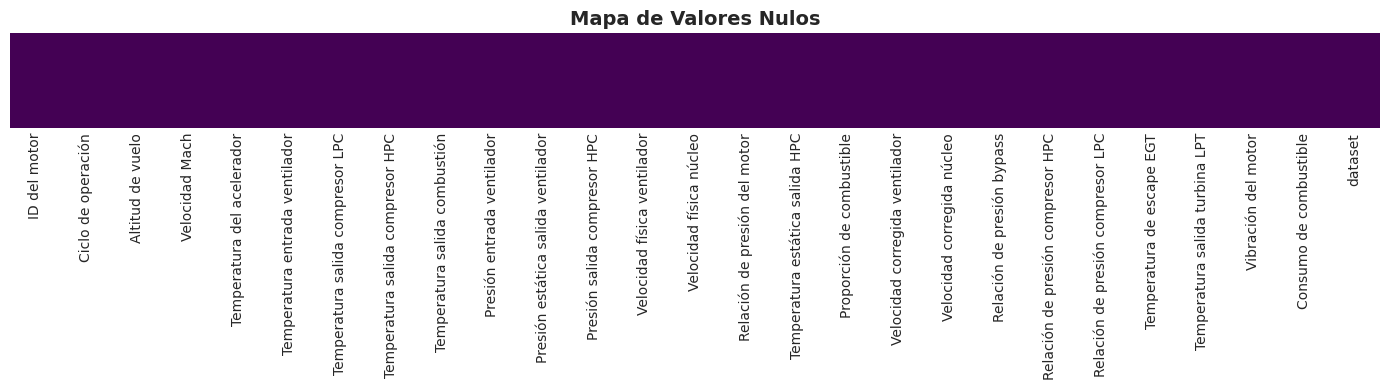

In [10]:
# Mapa visual de valores nulos
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Valores Nulos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### PASO 4 — Creación de la Variable Objetivo: RUL
**RUL (Remaining Useful Life)** = Ciclos restantes antes de que falle el motor.

Se calcula como: `RUL = ciclo_máximo_del_motor - ciclo_actual`

 VARIABLE OBJETIVO — RUL
RUL mínimo: 0 ciclos  (motor a punto de fallar)
RUL máximo: 542 ciclos
RUL promedio: 122.33 ciclos

Total columnas ahora: 28
Total filas: 160,359


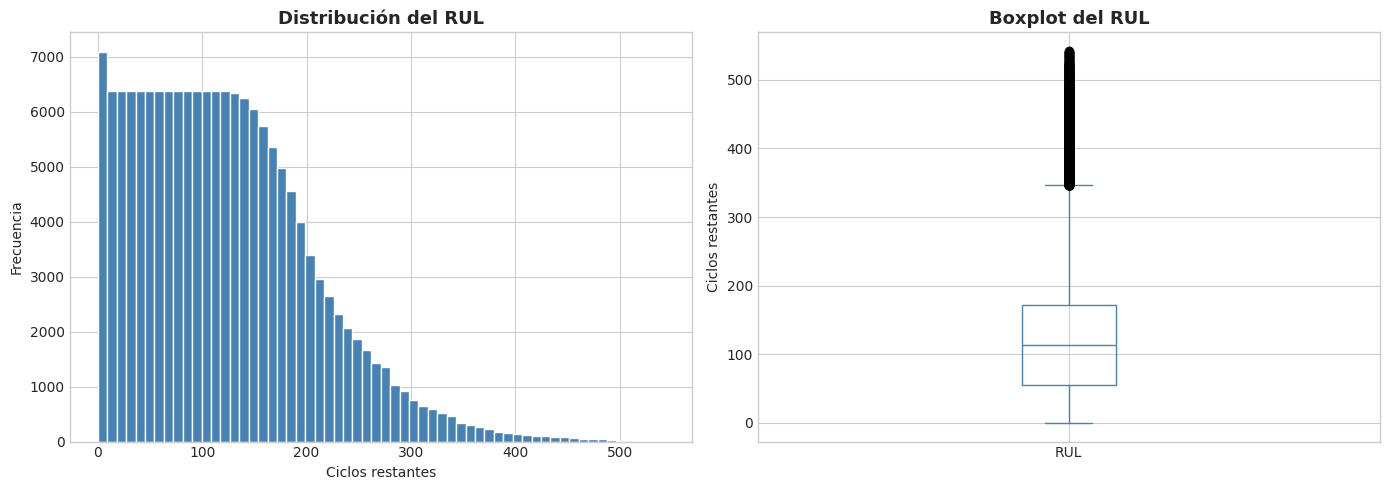

In [11]:
# Calcular RUL
max_cycles = df.groupby(['dataset', 'ID del motor'])['Ciclo de operación'].max().reset_index()
max_cycles.columns = ['dataset', 'ID del motor', 'max_Ciclo de operación']
df = df.merge(max_cycles, on=['dataset', 'ID del motor'])
df['RUL'] = df['max_Ciclo de operación'] - df['Ciclo de operación']
df = df.drop(columns=['max_Ciclo de operación'])







print('=' * 50)
print(' VARIABLE OBJETIVO — RUL')
print('=' * 50)
print(f'RUL mínimo: {df["RUL"].min()} ciclos  (motor a punto de fallar)')
print(f'RUL máximo: {df["RUL"].max()} ciclos')
print(f'RUL promedio: {df["RUL"].mean():.2f} ciclos')
print(f'\nTotal columnas ahora: {df.shape[1]}')
print(f'Total filas: {df.shape[0]:,}')

# Distribución del RUL
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['RUL'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del RUL', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ciclos restantes')
axes[0].set_ylabel('Frecuencia')

df['RUL'].plot(kind='box', ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot del RUL', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Ciclos restantes')

plt.tight_layout()
plt.show()

a distribución es asimétrica hacia la derecha (sesgada positivamente):

La mayoría de registros se concentran en RUL bajo (0–100 ciclos), es decir, el dataset tiene muchas más observaciones de motores cerca del fallo
A medida que aumentan los ciclos restantes, hay menos registros — lógico, porque cada motor empieza con RUL alto y va bajando hasta 0.

 Boxplot del RUL

Mediana ≈ 110 ciclos — la mitad de los registros tienen menos de ~110 ciclos restantes
IQR (caja) entre ~0 y ~170 ciclos — el 50% central de los datos
Bigote superior muy largo hasta ~350 ciclos
Outliers (puntos negros) hasta 542 ciclos — motores con vida útil excepcionalmente larga.

In [12]:
df['RUL'].describe()

count    160359.000000
mean        122.331338
std          83.538146
min           0.000000
25%          56.000000
50%         113.000000
75%         172.000000
max         542.000000
Name: RUL, dtype: float64

La variable objetivo RUL presenta una distribución asimétrica positiva, con valores entre 0 y 542 ciclos y una media de 122.33. La alta concentración de registros en valores bajos de RUL refleja la naturaleza acumulativa de las series temporales: cada motor aporta muchos ciclos finales cercanos al fallo y pocos ciclos iniciales. El boxplot evidencia que el 50% de los registros se sitúa por debajo de los 110 ciclos restantes, con presencia de valores atípicos superiores correspondientes a motores de vida útil prolongada. Esta asimetría deberá tenerse en cuenta al entrenar modelos predictivos, ya que el dataset está naturalmente desbalanceado hacia estados de degradación avanzada.

In [13]:
sensores = [
    'Altitud de vuelo', 'Velocidad Mach', 'Temperatura del acelerador',
    'Temperatura entrada ventilador', 'Temperatura salida compresor LPC',
    'Temperatura salida compresor HPC', 'Temperatura salida combustión',
    'Presión entrada ventilador', 'Presión estática salida ventilador',
    'Presión salida compresor HPC', 'Velocidad física ventilador',
    'Velocidad física núcleo', 'Relación de presión del motor',
    'Temperatura estática salida HPC', 'Proporción de combustible',
    'Velocidad corregida ventilador', 'Velocidad corregida núcleo',
    'Relación de presión bypass', 'Relación de presión compresor HPC',
    'Relación de presión compresor LPC', 'Temperatura de escape EGT',
    'Temperatura salida turbina LPT', 'Vibración del motor', 'Consumo de combustible'
]



###  PASO 5 Análisis de Variables Numéricas

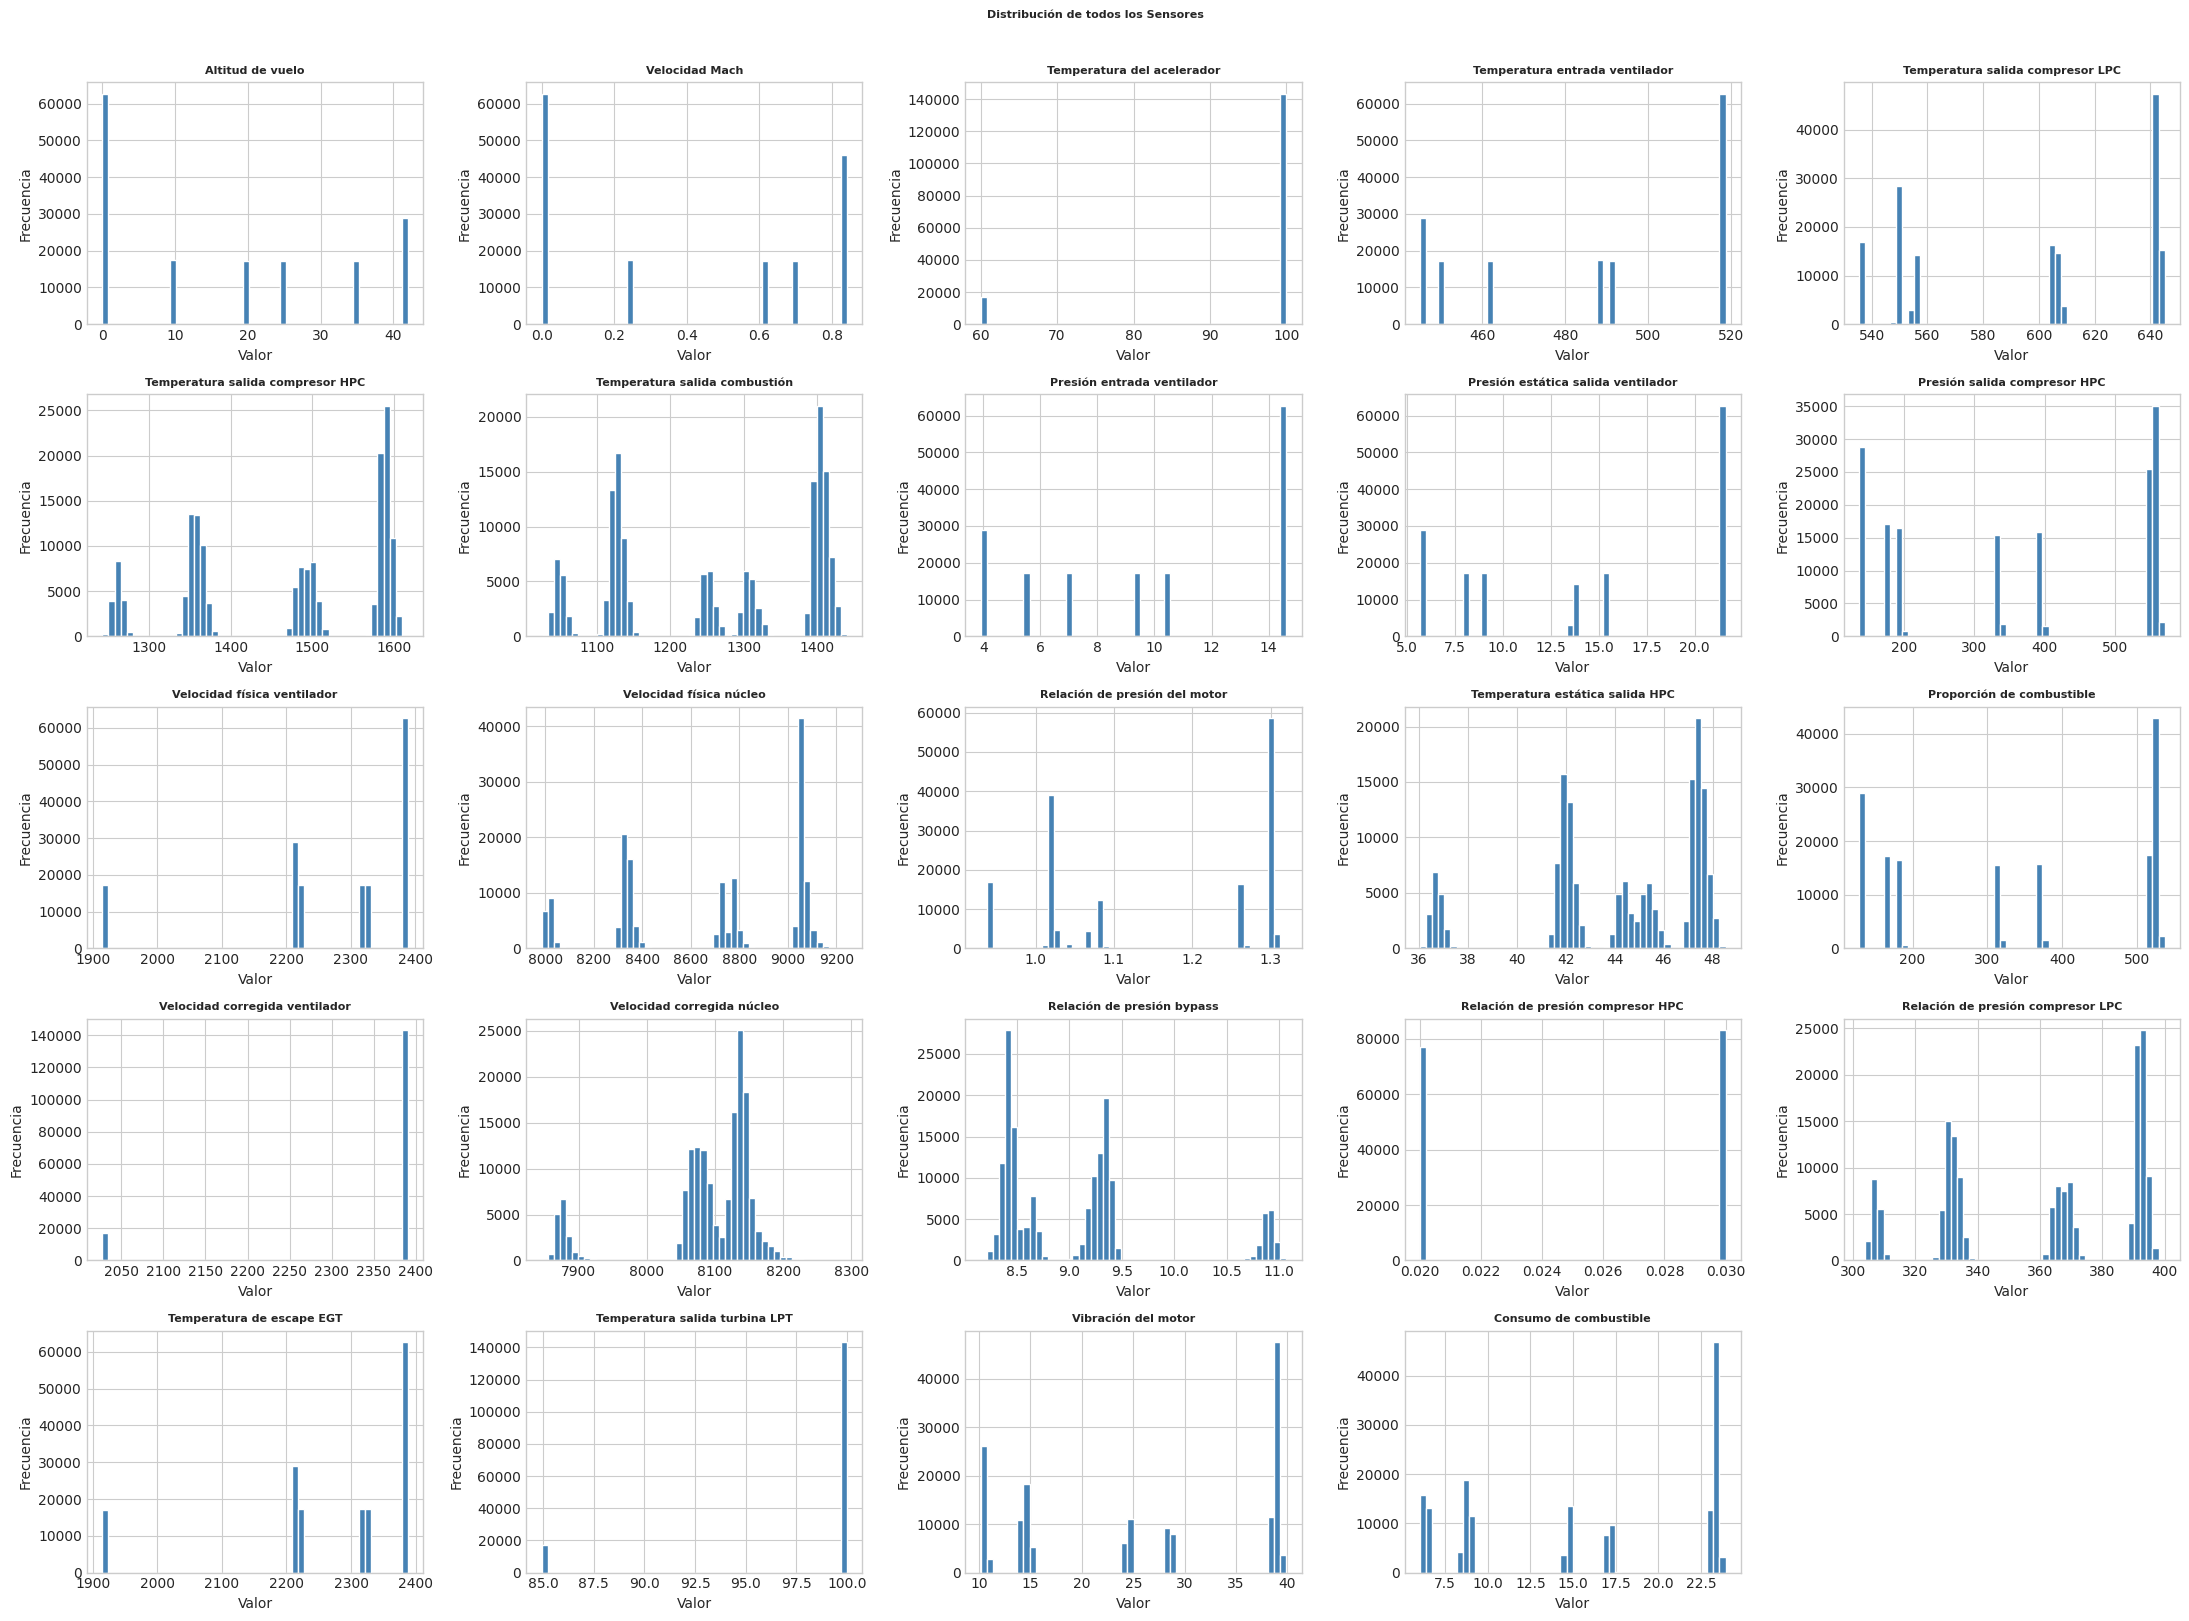

In [14]:
# Columnas a excluir (no son sensores)
excluir = ['ID del motor', 'Ciclo de operación', 'dataset', 'RUL']
sensores = [col for col in df.columns if col not in excluir]

# Distribución de todos los sensores
fig, axes = plt.subplots(5, 5, figsize=(22, 16))
axes = axes.flatten()

for i, sensor in enumerate(sensores):
    axes[i].hist(df[sensor], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(sensor, fontweight='bold', fontsize=8)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

for j in range(len(sensores), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de todos los Sensores', fontsize=8, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Temperatura salida compresor HPC, Velocidad física núcleo, Velocidad corregida núcleo, entre otros — tienen forma de campana centrada, lo que indica un comportamiento estable y predecible. Son buenos candidatos para el modelo.

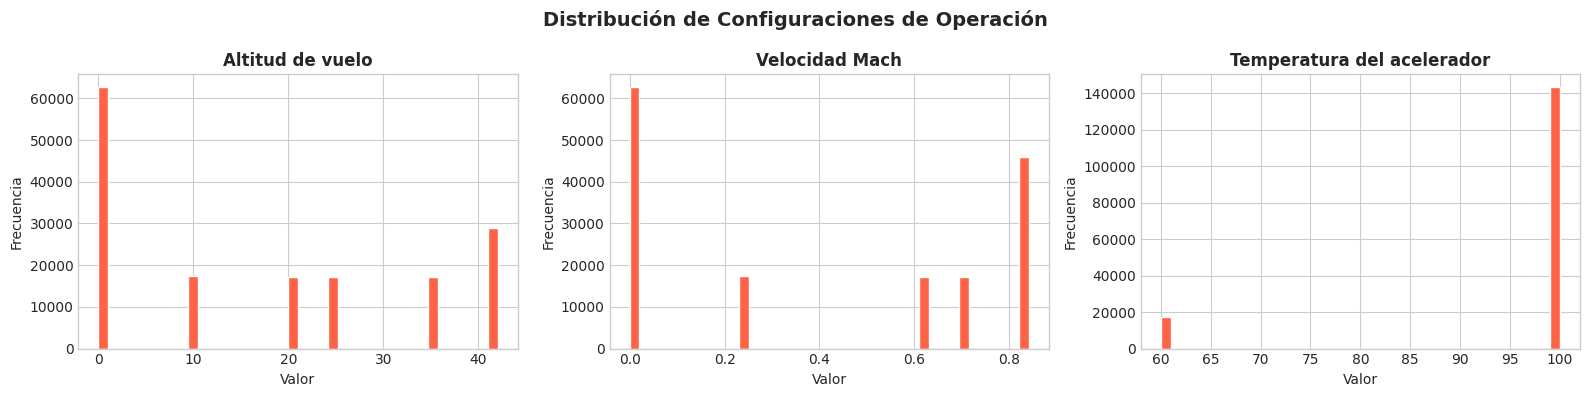

In [15]:


# Distribución de configuraciones de operación
operaciones = ['Altitud de vuelo', 'Velocidad Mach', 'Temperatura del acelerador']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, op in enumerate(operaciones):
    axes[i].hist(df[op], bins=40, color='tomato', edgecolor='white')
    axes[i].set_title(op, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Configuraciones de Operación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Análisis de las Configuraciones de Operación

**op_setting_1** — Condición de altitud/carga
La distribución muestra 6 picos discretos en valores específicos (0, 10, 20, 25, 35, 42). Esto indica que el motor no opera en condiciones continuas sino en regímenes fijos predefinidos — como distintos niveles de altitud de vuelo. Es una variable discreta disfrazada de continua.

**op_setting_2** — Condición de velocidad/presión
Similar a la anterior, tiene picos en valores fijos (0.0, 0.25, 0.62, 0.70, 0.84). El motor opera bajo puntos de operación específicos, no de forma gradual. Confirma que los 4 subconjuntos FD001–FD004 tienen distintas combinaciones de estas condiciones.

**op_setting_3** — Régimen del motor
Es la más extrema: casi el 90% de los registros están en 100, con muy pocos en 60. Prácticamente es una variable binaria o constante, lo que la hace poco útil para predecir RUL.

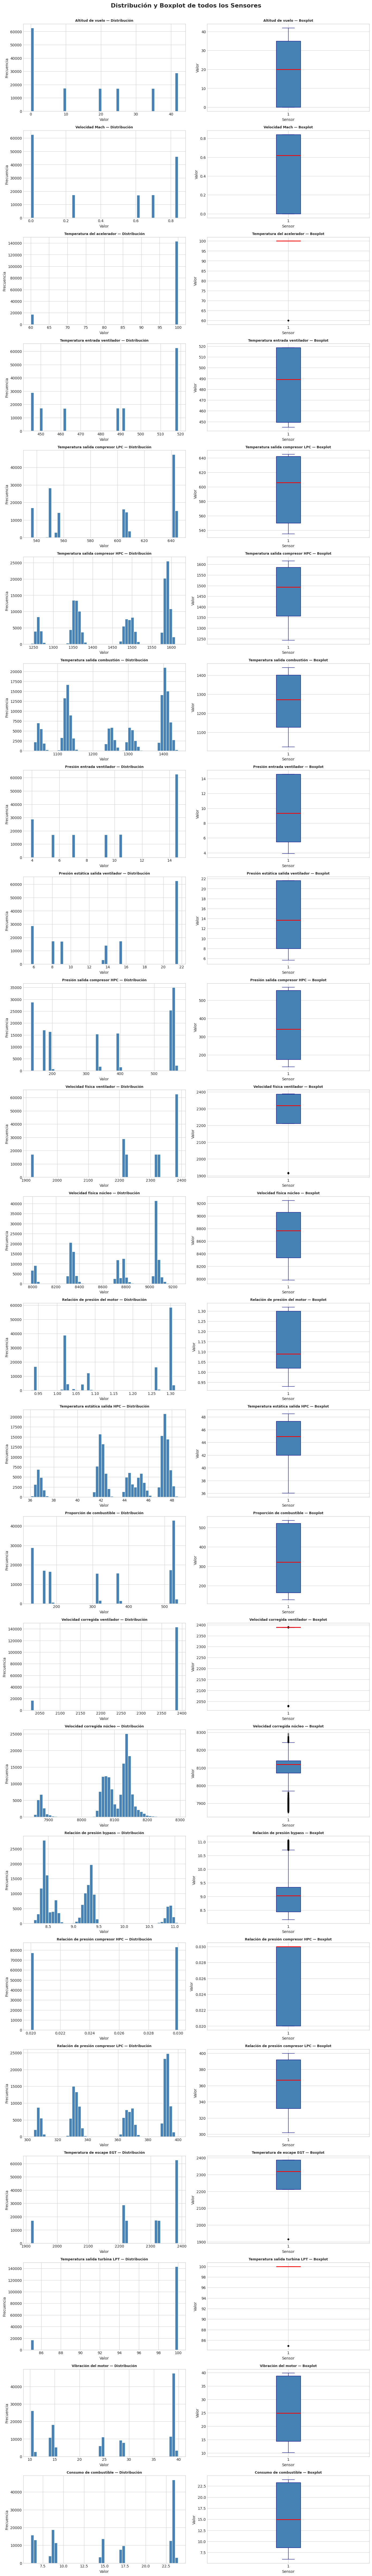

In [16]:
excluir = ['ID del motor', 'Ciclo de operación', 'dataset', 'RUL']
sensores = [col for col in df.columns if col not in excluir]

fig, axes = plt.subplots(len(sensores), 2, figsize=(14, len(sensores) * 4))

for i, sensor in enumerate(sensores):
    # Histograma
    axes[i, 0].hist(df[sensor], bins=50, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{sensor} — Distribución', fontweight='bold', fontsize=9)
    axes[i, 0].set_xlabel('Valor')
    axes[i, 0].set_ylabel('Frecuencia')

    # Boxplot
    axes[i, 1].boxplot(df[sensor].dropna(), patch_artist=True,
                        boxprops=dict(facecolor='steelblue', color='navy'),
                        medianprops=dict(color='red', linewidth=2),
                        whiskerprops=dict(color='navy'),
                        capprops=dict(color='navy'),
                        flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=3))
    axes[i, 1].set_title(f'{sensor} — Boxplot', fontweight='bold', fontsize=9)
    axes[i, 1].set_xlabel('Sensor')
    axes[i, 1].set_ylabel('Valor')

plt.suptitle('Distribución y Boxplot de todos los Sensores', fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()


### PASO 6 — Selección de Variables Predictoras
Identificamos qué sensores tienen poca varianza y no aportan al modelo.

📊 Varianza de cada sensor:
Relación de presión compresor HPC          0.000025
Relación de presión del motor              0.020193
Velocidad Mach                             0.135379
Relación de presión bypass                 0.564874
Temperatura estática salida HPC           11.739821
Presión entrada ventilador                18.194955
Temperatura salida turbina LPT            21.680849
Presión estática salida ventilador        41.524136
Consumo de combustible                    49.211164
Vibración del motor                      136.689346
Temperatura del acelerador               152.745974
Altitud de vuelo                         273.174400
Temperatura entrada ventilador           925.400015
Relación de presión compresor LPC        962.329127
Temperatura salida compresor LPC        1804.424361
Velocidad corregida núcleo              6500.109571
Velocidad corregida ventilador         12358.155761
Temperatura salida compresor HPC       13965.392208
Temperatura salida combustión        

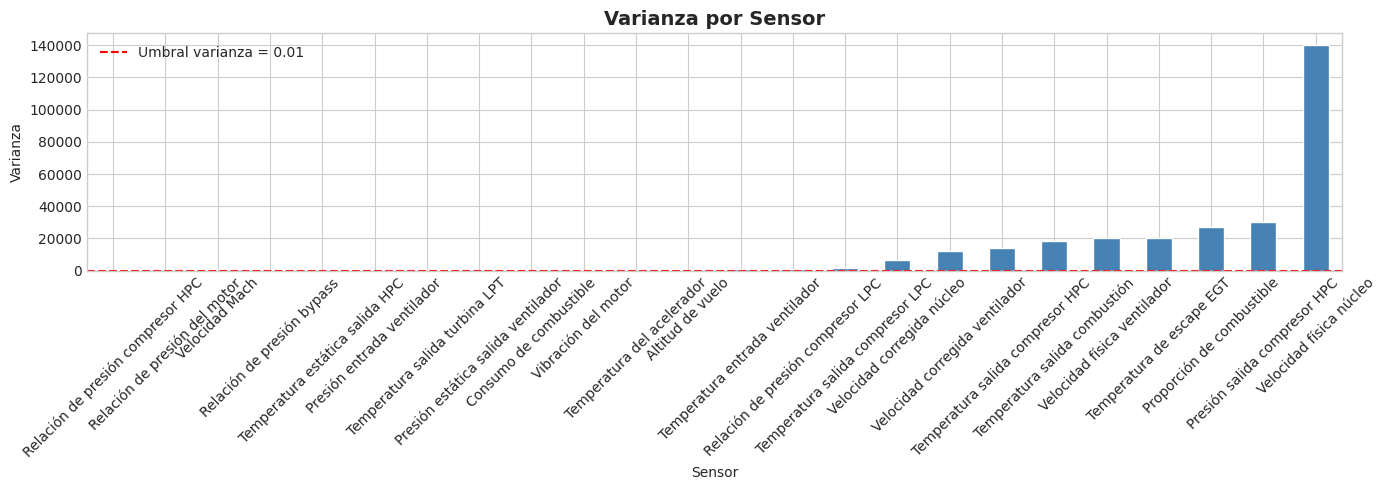


❌ Sensores con varianza baja (descartar): ['Relación de presión compresor HPC']

✅ Sensores útiles para el modelo (23): ['Relación de presión del motor', 'Velocidad Mach', 'Relación de presión bypass', 'Temperatura estática salida HPC', 'Presión entrada ventilador', 'Temperatura salida turbina LPT', 'Presión estática salida ventilador', 'Consumo de combustible', 'Vibración del motor', 'Temperatura del acelerador', 'Altitud de vuelo', 'Temperatura entrada ventilador', 'Relación de presión compresor LPC', 'Temperatura salida compresor LPC', 'Velocidad corregida núcleo', 'Velocidad corregida ventilador', 'Temperatura salida compresor HPC', 'Temperatura salida combustión', 'Velocidad física ventilador', 'Temperatura de escape EGT', 'Proporción de combustible', 'Presión salida compresor HPC', 'Velocidad física núcleo']


In [17]:
# Calcular varianza de cada sensor
varianza = df[sensores].var().sort_values()

print('📊 Varianza de cada sensor:')
print(varianza.round(6))

# Gráfica de varianza
plt.figure(figsize=(14, 5))
varianza.plot(kind='bar', color='steelblue', edgecolor='white')
plt.axhline(y=0.01, color='red', linestyle='--', label='Umbral varianza = 0.01')
plt.title('Varianza por Sensor', fontsize=14, fontweight='bold')
plt.xlabel('Sensor')
plt.ylabel('Varianza')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Identificar sensores útiles y a descartar
umbral = 0.01
sensores_bajos = varianza[varianza < umbral].index.tolist()
sensores_utiles = varianza[varianza >= umbral].index.tolist()

print(f'\n❌ Sensores con varianza baja (descartar): {sensores_bajos}')
print(f'\n✅ Sensores útiles para el modelo ({len(sensores_utiles)}): {sensores_utiles}')

Se estableció un umbral de varianza de 0.01 para identificar sensores con comportamiento constante. Este valor fue elegido de forma práctica dado que los sensores no informativos presentan varianzas prácticamente nulas, mientras que los sensores útiles superan ampliamente dicho umbral, haciendo que la elección del valor exacto no afecte el resultado de la selección."

In [18]:
# Resumen final de variables
features = ['Ciclo de operación', 'Altitud de vuelo', 'Velocidad Mach', 'Temperatura del acelerador'] + sensores_utiles

print('=' * 55)
print('📋 RESUMEN DE VARIABLES PARA EL MODELO')
print('=' * 55)
print(f'\n🎯 Variable Objetivo:')
print(f'   → RUL (Vida Útil Restante)')
print(f'\n📊 Variables Predictoras ({len(features)}):')
for f in features:
    print(f'   → {f}')
print(f'\n❌ Variables descartadas:')
print(f'   → ID del motor (identificador, no aporta)')
print(f'   → dataset (etiqueta interna)')
for s in sensores_bajos:
    print(f'   → {s} (varianza muy baja)')

📋 RESUMEN DE VARIABLES PARA EL MODELO

🎯 Variable Objetivo:
   → RUL (Vida Útil Restante)

📊 Variables Predictoras (27):
   → Ciclo de operación
   → Altitud de vuelo
   → Velocidad Mach
   → Temperatura del acelerador
   → Relación de presión del motor
   → Velocidad Mach
   → Relación de presión bypass
   → Temperatura estática salida HPC
   → Presión entrada ventilador
   → Temperatura salida turbina LPT
   → Presión estática salida ventilador
   → Consumo de combustible
   → Vibración del motor
   → Temperatura del acelerador
   → Altitud de vuelo
   → Temperatura entrada ventilador
   → Relación de presión compresor LPC
   → Temperatura salida compresor LPC
   → Velocidad corregida núcleo
   → Velocidad corregida ventilador
   → Temperatura salida compresor HPC
   → Temperatura salida combustión
   → Velocidad física ventilador
   → Temperatura de escape EGT
   → Proporción de combustible
   → Presión salida compresor HPC
   → Velocidad física núcleo

❌ Variables descartadas:
   →


### PASO 7 — Correlación entre Variables numericas

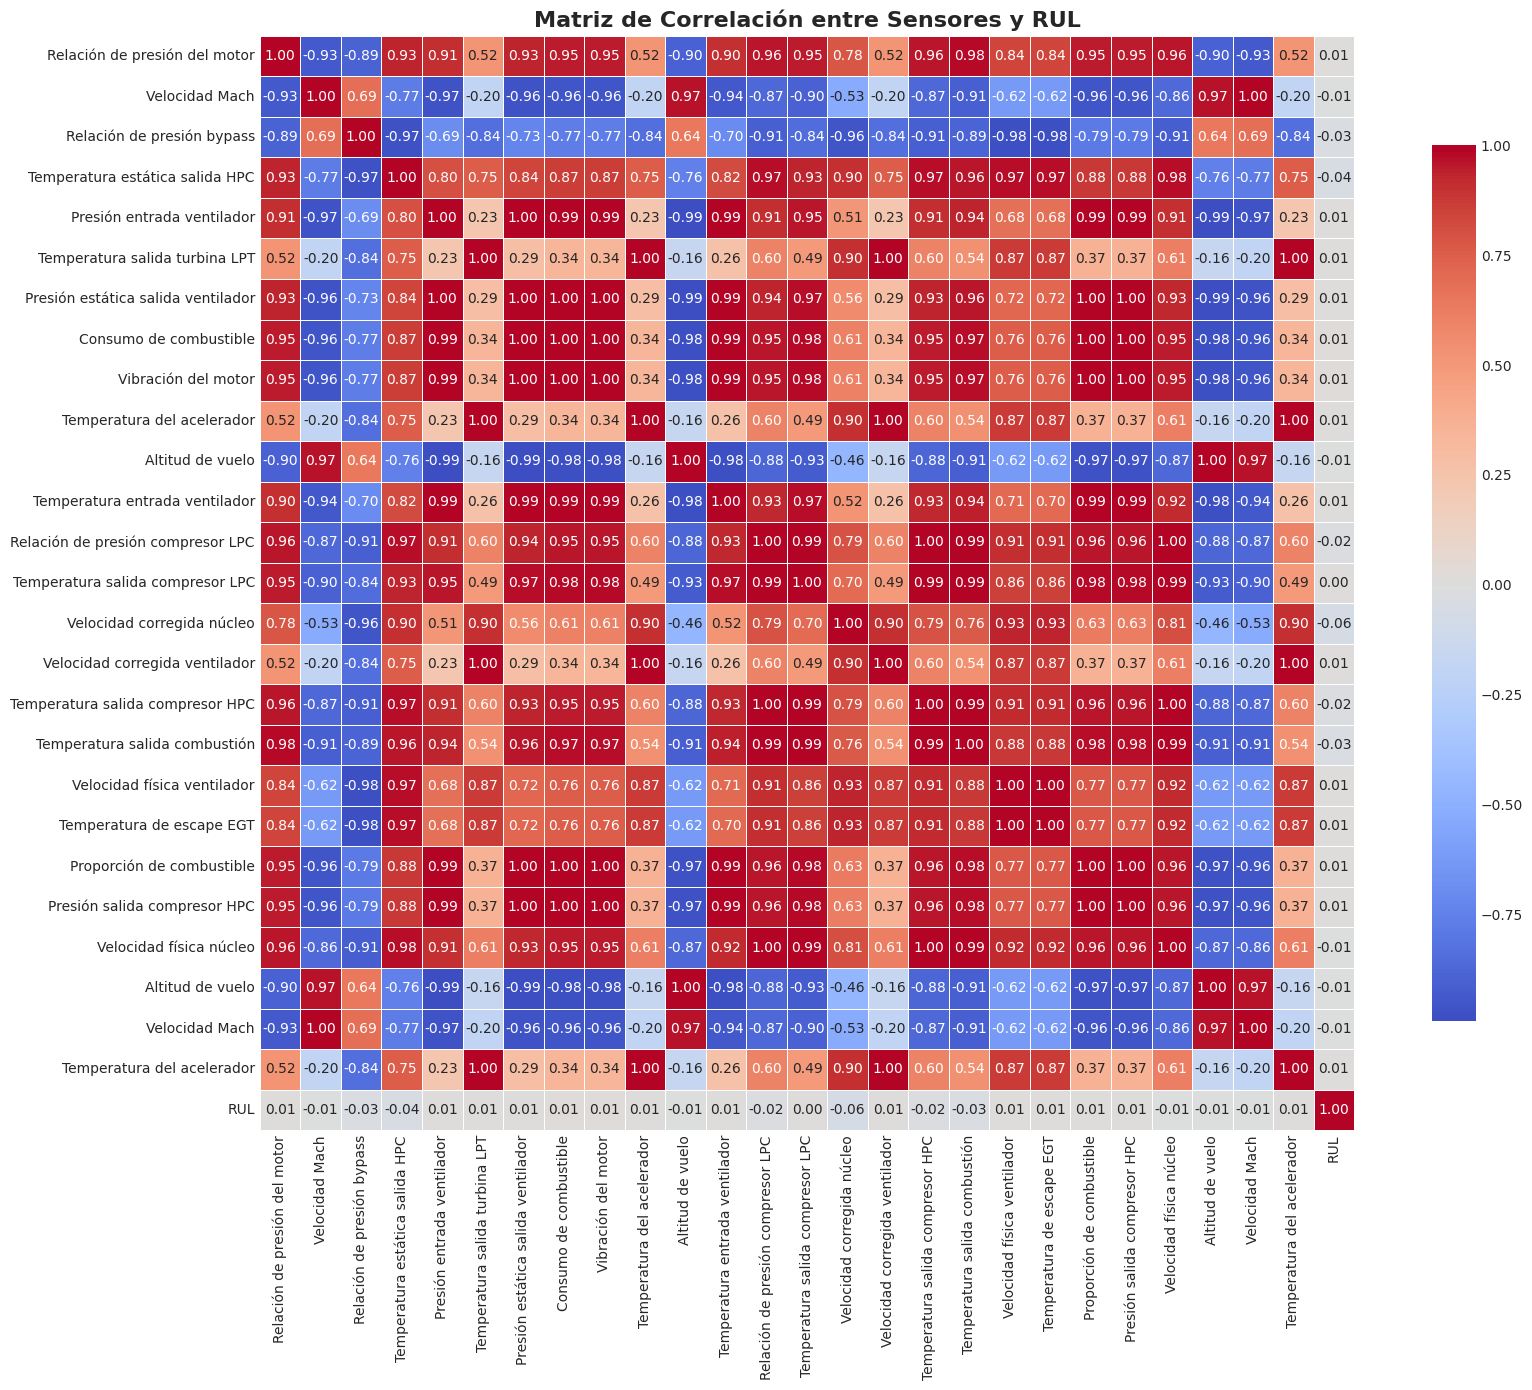

In [19]:
cols_corr = sensores_utiles + ['Altitud de vuelo', 'Velocidad Mach', 'Temperatura del acelerador', 'RUL']
corr_matrix = df[cols_corr].corr()

# Heatmap completo
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación entre Sensores y RUL', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

La matriz de correlación revela que ningún sensor presenta correlación lineal significativa con el RUL, con coeficientes cercanos a cero en todos los casos. Esto sugiere que la degradación del motor es un fenómeno no lineal que no puede capturarse mediante relaciones simples entre variables individuales y la vida útil restante. Sin embargo, se observa una alta multicolinealidad entre los propios sensores, con correlaciones superiores a 0.90 entre varios pares, lo que indica redundancia de información y abre la posibilidad de reducción de dimensionalidad. **El análisis predictivo requerirá modelos capaces de capturar interacciones complejas entre múltiples variables a lo largo del tiempo.**???

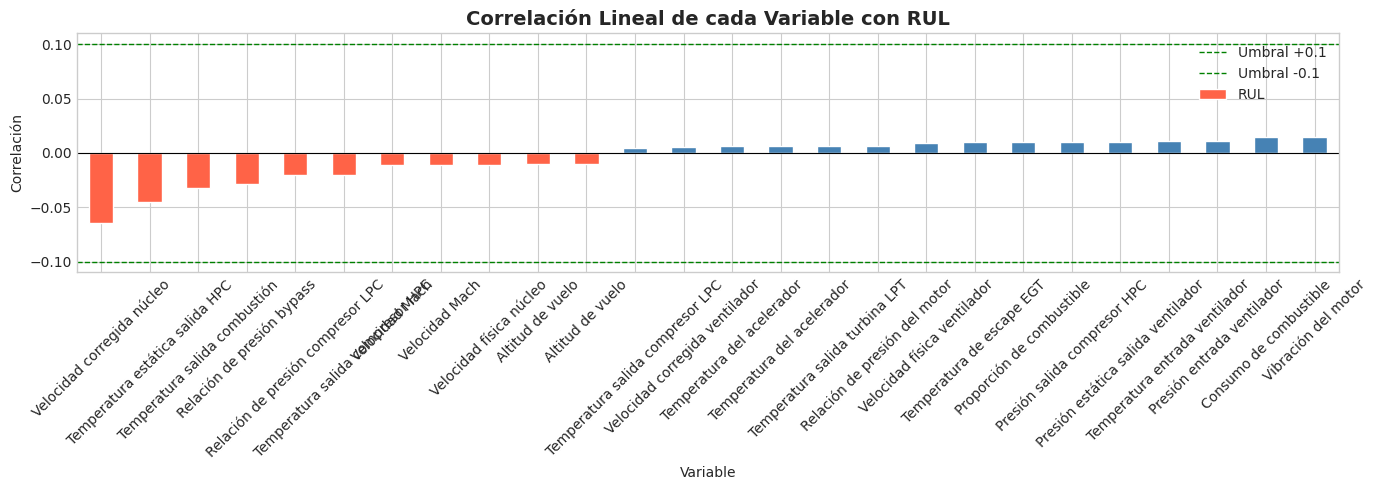

🔝 Top 10 variables más correlacionadas con RUL:
Velocidad corregida núcleo           0.064813
Temperatura estática salida HPC      0.044859
Temperatura salida combustión        0.032047
Relación de presión bypass           0.028528
Relación de presión compresor LPC    0.020581
Temperatura salida compresor HPC     0.020455
Vibración del motor                  0.014697
Consumo de combustible               0.014656
Velocidad Mach                       0.011275
Velocidad Mach                       0.011275
Name: RUL, dtype: float64


In [20]:
# Correlación específica con RUL
corr_rul = corr_matrix['RUL'].drop('RUL').sort_values()

plt.figure(figsize=(14, 5))
corr_rul.plot(kind='bar',
              color=['tomato' if x < 0 else 'steelblue' for x in corr_rul],
              edgecolor='white')
plt.title('Correlación Lineal de cada Variable con RUL', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.axhline(y=0.1, color='green', linestyle='--', linewidth=1, label='Umbral +0.1')
plt.axhline(y=-0.1, color='green', linestyle='--', linewidth=1, label='Umbral -0.1')
plt.xlabel('Variable')
plt.ylabel('Correlación')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('🔝 Top 10 variables más correlacionadas con RUL:')
print(corr_rul.abs().sort_values(ascending=False).head(10))


El análisis de correlación lineal individual confirma que ninguna variable del dataset supera el umbral de ±0.1 respecto al RUL. Los sensores con mayor señal son sensor_14 y sensor_11 


### PASO 8 — Evolución de Sensores por Ciclo
Visualizamos cómo cambian los sensores más importantes a medida que el motor se acerca a la falla.

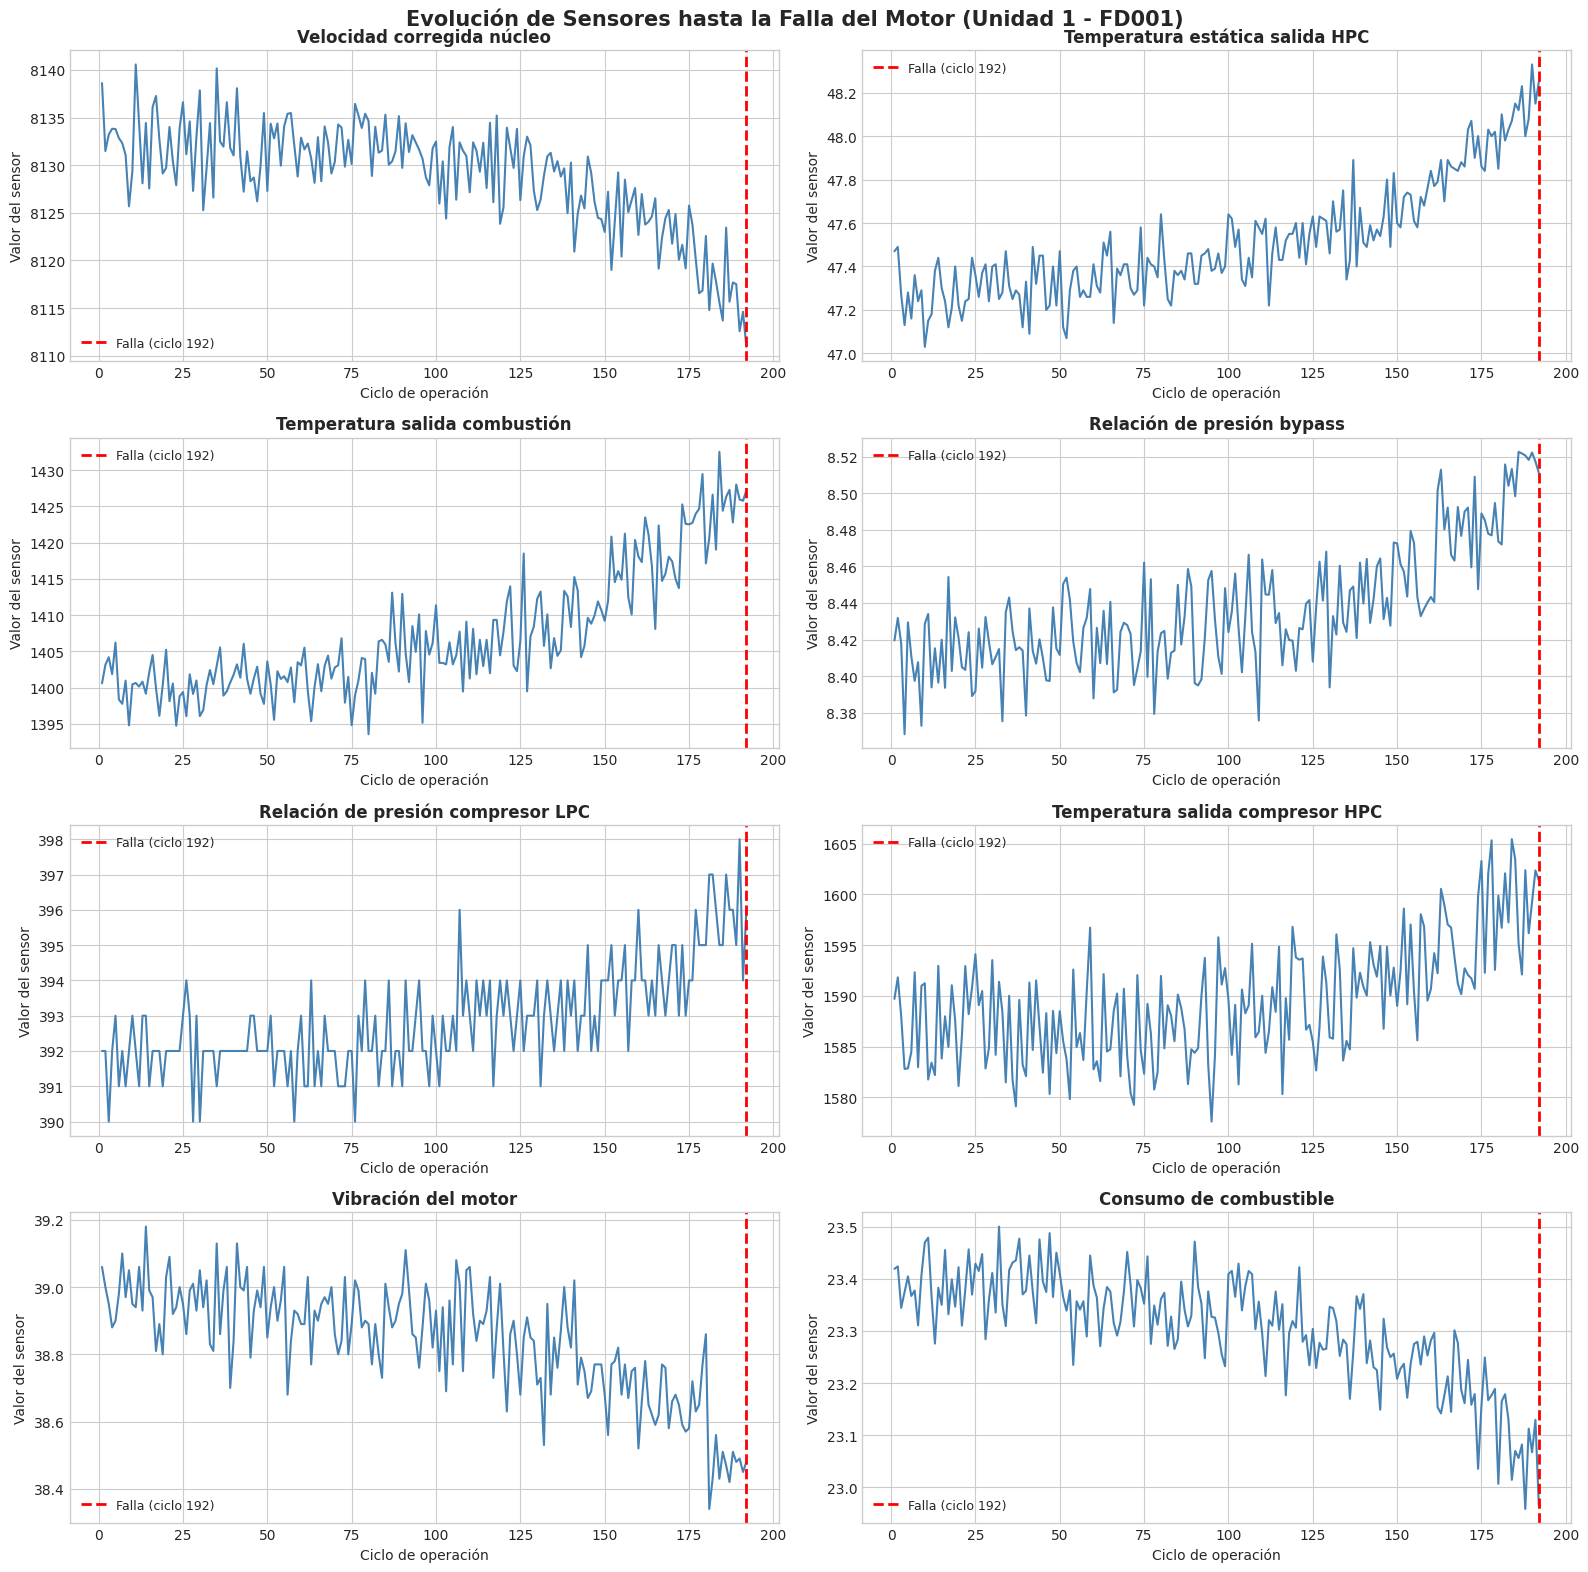

In [21]:
motor = df[(df['ID del motor'] == 1) & (df['dataset'] == 'FD001')].copy()
ciclo_falla = motor['Ciclo de operación'].max()  # ← C mayúscula

# Top 8 sensores más correlacionados con RUL
sensores_top = corr_rul.abs().sort_values(ascending=False).head(8).index.tolist()

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, sensor in enumerate(sensores_top):
    axes[i].plot(motor['Ciclo de operación'], motor[sensor], color='steelblue', linewidth=1.5)  # ← C mayúscula
    axes[i].axvline(x=ciclo_falla, color='red', linestyle='--', linewidth=2, label=f'Falla (ciclo {ciclo_falla})')
    axes[i].set_title(f'{sensor}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Ciclo de operación')
    axes[i].set_ylabel('Valor del sensor')
    axes[i].legend(fontsize=9)

plt.suptitle('Evolución de Sensores hasta la Falla del Motor (Unidad 1 - FD001)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Análisis de Evolución de Sensores hasta el Fallo

🔴 La línea roja punteada
Marca el momento del fallo del motor (ciclo ~190). Todo lo que ocurre antes es la vida operativa del motor hasta su colapso.

**Conclusión clave**

**Aunque la correlación lineal individual era débil (vista en la gráfica anterior), visualmente sí existe una tendencia de degradación en todos los sensores. El ruido ciclo a ciclo ocultaba esa señal en la correlación.**

**Esto confirma que el modelo necesita capturar la tendencia temporal acumulada, no solo el valor puntual de cada ciclo?????????????**


El análisis temporal del Motor 1 del subconjunto FD001 revela que, pese a la baja correlación lineal observada anteriormente, los sensores sí exhiben tendencias de degradación progresiva conforme el motor se aproxima al fallo. Sensores como sensor_4, sensor_11 y sensor_3 muestran una tendencia ascendente sostenida, mientras que sensor_14, sensor_20 y sensor_21 descienden gradualmente. Este comportamiento confirma que la señal de degradación existe pero está enmascarada por ruido operativo ciclo a ciclo, justificando el uso de modelos que consideren la evolución temporal de las lecturas

📈 Patrones de degradación por sensor:

| Sensor | Comportamiento | Interpretación |
|---|---|---|
| sensor_14 | Baja progresivamente hacia el fallo | A medida que el motor se degrada, este valor cae — buena señal de deterioro |
| sensor_11| Sube progresivamente hacia el fallo | Aumenta con la degradación — posiblemente temperatura o presión creciente |
| sensor_4 |Tendencia ascendente clara | Sube consistentemente — muy buen indicador de degradación |
| sensor_15 | Sube hacia el fallo | Señal de deterioro progresivo | 
| sensor_17 | Sube con ruido | Tendencia ascendente con variabilidad | 
| sensor_3S | Sube progresivamente | Indicador claro de desgaste | 
| sensor_20 | Baja hacia el fallo | Cae conforme se acerca el fallo | 
| sensor_21 | Baja hacia el fallo | Similar a sensor_20, descenso progresivo |

In [22]:
# Comparar múltiples motores — promedio de sensor_11 por ciclo
df_fd001 = df[df['dataset'] == 'FD001'].copy()

# Normalizar ciclos al revés (0 = falla, negativo = ciclos antes de la falla)
promedio_sensor = df_fd001.groupby('cycle')['sensor_11'].mean()

plt.figure(figsize=(12, 5))
plt.plot(promedio_sensor.index, promedio_sensor.values, color='steelblue', linewidth=2)
plt.title('Promedio de sensor_11 por Ciclo (todos los motores FD001)',
          fontsize=13, fontweight='bold')
plt.xlabel('Ciclo de operación')
plt.ylabel('Temperatura promedio sensor_11')
plt.tight_layout()
plt.show()

KeyError: 'cycle'

Se seleccionó sensor_11 como sensor representativo para el análisis de tendencia grupal por ser uno de los que mostró mayor claridad en su patrón ascendente de degradación, además de corresponder físicamente a una medición de temperatura que aumenta naturalmente con el deterioro del motor


### PASO 9 — Resumen y Conclusiones del EDA

In [ ]:
print('=' * 60)
print('RESUMEN FINAL DEL EDA')
print('=' * 60)

print(f'''
DATASET:
   → Fuente: NASA CMAPSS Turbofan Engine Dataset
   → Filas totales: {df.shape[0]:,}
   → Columnas totales: {df.shape[1]}
   → Valores nulos: 0

VARIABLE OBJETIVO:
   → RUL (Remaining Useful Life)
   → Rango: 0 a {df['RUL'].max()} ciclos
   → Promedio: {df['RUL'].mean():.1f} ciclos

VARIABLES PREDICTORAS:
   → {len(features)} variables en total
   → cycle + 3 configuraciones + {len(sensores_utiles)} sensores útiles
   → {len(sensores_bajos)} sensores descartados por baja varianza: {sensores_bajos}

HALLAZGOS CLAVE:
   → Correlación lineal baja con RUL (max ~0.06)
     → La relación es NO LINEAL, ideal para Random Forest
   → Sensores más importantes: sensor_14, sensor_11, sensor_4
   → Los sensores muestran degradación gradual hasta la falla
   → Alta correlación entre sensores (redundancia)


''')

print('=' * 60)
print('✅ EDA COMPLETO')
print('=' * 60)

RESUMEN FINAL DEL EDA

DATASET:
   → Fuente: NASA CMAPSS Turbofan Engine Dataset
   → Filas totales: 160,359
   → Columnas totales: 28
   → Valores nulos: 0

VARIABLE OBJETIVO:
   → RUL (Remaining Useful Life)
   → Rango: 0 a 542 ciclos
   → Promedio: 122.3 ciclos

VARIABLES PREDICTORAS:
   → 24 variables en total
   → cycle + 3 configuraciones + 20 sensores útiles
   → 1 sensores descartados por baja varianza: ['sensor_16']

HALLAZGOS CLAVE:
   → Correlación lineal baja con RUL (max ~0.06)
     → La relación es NO LINEAL, ideal para Random Forest
   → Sensores más importantes: sensor_14, sensor_11, sensor_4
   → Los sensores muestran degradación gradual hasta la falla
   → Alta correlación entre sensores (redundancia)



✅ EDA COMPLETO


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

print('=' * 50)
print(' PREPROCESAMIENTO DEL DATASET')
print('=' * 50)

# ── PASO 1: Eliminar sensores de baja varianza ──
sensores_a_eliminar = ['sensor_1', 'sensor_5', 'sensor_6', 
                        'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
sensores_finales = [s for s in sensores if s not in sensores_a_eliminar]
print(f'\n✅ Sensores eliminados por baja varianza: {sensores_a_eliminar}')
print(f'✅ Sensores conservados ({len(sensores_finales)}): {sensores_finales}')

# ── PASO 2: Cappar RUL máximo ──
RUL_MAX = 125
df['RUL'] = df['RUL'].clip(upper=RUL_MAX)
print(f'\n✅ RUL cappado a máximo {RUL_MAX} ciclos')
print(f'   RUL máximo ahora: {df["RUL"].max()}')
print(f'   RUL promedio ahora: {df["RUL"].mean():.2f}')

# ── PASO 3: Separar features y variable objetivo ──
X = df[sensores_finales + ['cycle', 'op_setting_1', 'op_setting_2']]
y = df['RUL']
print(f'\n✅ Features seleccionadas: {X.shape[1]} columnas')
print(f'✅ Variable objetivo: RUL ({y.shape[0]} registros)')

# ── PASO 4: Escalar variables ──
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print(f'\n✅ Escalado MinMaxScaler aplicado')
print(f'   Rango después del escalado: [{X_scaled.min().min():.2f}, {X_scaled.max().max():.2f}]')

# ── PASO 5: Split train/test ──
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f'\n✅ División train/test (80/20):')
print(f'   Train: {X_train.shape[0]:,} registros')
print(f'   Test:  {X_test.shape[0]:,} registros')

print('\n' + '=' * 50)
print('🎯 DATASET LISTO PARA ENTRENAR EL MODELO')
print('=' * 50)

 PREPROCESAMIENTO DEL DATASET

✅ Sensores eliminados por baja varianza: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
✅ Sensores conservados (14): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

✅ RUL cappado a máximo 125 ciclos
   RUL máximo ahora: 125
   RUL promedio ahora: 90.18

✅ Features seleccionadas: 17 columnas
✅ Variable objetivo: RUL (160359 registros)

✅ Escalado MinMaxScaler aplicado
   Rango después del escalado: [0.00, 1.00]

✅ División train/test (80/20):
   Train: 128,287 registros
   Test:  32,072 registros

🎯 DATASET LISTO PARA ENTRENAR EL MODELO


PRÓXIMO PASO:
   → Entrenar modelo Random Forest para predecir RUL
   → Aplicar RUL cap = 125 para mejorar el modelo
   → Objetivo: R² > 0.85

In [ ]:
import pandas as pd
import numpy as np
import os

# Crear carpeta data si no existe
os.makedirs("data", exist_ok=True)

# -----------------------------
# 1. Definir columnas EXACTAS en español
# -----------------------------
columnas = [
    "ID del motor", "Ciclo de operación",
    "Altitud de vuelo", "Velocidad Mach", "Temperatura del acelerador",
    "Temperatura entrada ventilador", "Temperatura salida compresor LPC",
    "Temperatura salida compresor HPC", "Temperatura salida combustión",
    "Presión entrada ventilador", "Presión estática salida ventilador",
    "Presión salida compresor HPC", "Velocidad física ventilador",
    "Velocidad física núcleo", "Relación de presión del motor",
    "Temperatura estática salida HPC", "Proporción de combustible",
    "Velocidad corregida ventilador", "Velocidad corregida núcleo",
    "Relación de presión bypass", "Relación de presión compresor HPC",
    "Relación de presión compresor LPC", "Temperatura de escape EGT",
    "Temperatura salida turbina LPT", "Vibración del motor",
    "Consumo de combustible"
]

# -----------------------------
# 2. Función para cargar cada FD
# -----------------------------
def cargar_fd(ruta_train, ruta_rul, nombre_fd):
    df = pd.read_csv(ruta_train, sep=" ", header=None)
    df = df.dropna(axis=1)
    df.columns = columnas
    df["dataset"] = nombre_fd

    # Cargar RUL real
    rul = pd.read_csv(ruta_rul, sep=" ", header=None)
    rul = rul.dropna(axis=1)
    rul.columns = ["RUL"]

    # Calcular RUL por motor
    df["RUL"] = df.groupby("ID del motor")["Ciclo de operación"].transform(
        lambda x: x.max() - x
    )

    return df

# -----------------------------
# 3. Cargar los 4 subconjuntos CMAPSS
# -----------------------------
base = "/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/"

FD001 = cargar_fd(base+"train_FD001.txt", base+"RUL_FD001.txt", "FD001")
FD002 = cargar_fd(base+"train_FD002.txt", base+"RUL_FD002.txt", "FD002")
FD003 = cargar_fd(base+"train_FD003.txt", base+"RUL_FD003.txt", "FD003")
FD004 = cargar_fd(base+"train_FD004.txt", base+"RUL_FD004.txt", "FD004")

# -----------------------------
# 4. Unir todo en un solo DataFrame
# -----------------------------
df = pd.concat([FD001, FD002, FD003, FD004], ignore_index=True)

# -----------------------------
# 5. Preprocesamiento igual al usado en tu modelo
# -----------------------------

# Sensores descartados por baja varianza (según tu EDA)
sensores_baja_var = [
    "Temperatura entrada ventilador",
    "Presión entrada ventilador",
    "Presión estática salida ventilador",
    "Relación de presión del motor",
    "Relación de presión compresor HPC",
    "Temperatura de escape EGT",
    "Temperatura salida turbina LPT"
]

df = df.drop(columns=sensores_baja_var)

# Cap RUL a 125 ciclos (como en tu notebook)
df["RUL"] = df["RUL"].clip(upper=125)

# -----------------------------
# 6. Guardar dataset final
# -----------------------------
df.to_csv("data/dataset.csv", index=False)

print("✔️ dataset.csv creado en /data/")
print(df.head())
print(df.shape)


✔️ dataset.csv creado en /data/
   ID del motor  Ciclo de operación  Altitud de vuelo  Velocidad Mach  \
0             1                   1           -0.0007         -0.0004   
1             1                   2            0.0019         -0.0003   
2             1                   3           -0.0043          0.0003   
3             1                   4            0.0007          0.0000   
4             1                   5           -0.0019         -0.0002   

   Temperatura del acelerador  Temperatura salida compresor LPC  \
0                       100.0                            641.82   
1                       100.0                            642.15   
2                       100.0                            642.35   
3                       100.0                            642.35   
4                       100.0                            642.37   

   Temperatura salida compresor HPC  Temperatura salida combustión  \
0                           1589.70                     